# ZOIDBERG2.0 — Détection de pneumonie sur radios thoraciques

**Diagnostic assisté par ordinateur** — Epitech

Ce rapport présente un **réseau de neurones convolutif (CNN) implémenté *from scratch* en NumPy**
(aucune librairie de deep learning) pour aider au diagnostic de la pneumonie à partir de
radiographies thoraciques.

## Sommaire
1. Présentation des données et exploration
2. Prétraitement des images
3. PCA — réduction de dimension et visualisation
4. Architecture du CNN maison
5. Procédure **train / validation / test**
6. **Simple train/test split** *vs* **validation croisée (cross-validation)**
7. **Tuning** des hyperparamètres
8. **Feature engineering** — impact du prétraitement (égalisation, standardisation)
9. Modèle binaire final & **métriques avancées (ROC-AUC, matrice de confusion)**
10. **Bonus — origine de la pneumonie (3 classes : NORMAL / VIRUS / BACTÉRIE)**
11. Synthèse des résultats

> ⚙️ Le CNN est codé à la main : la convolution utilise des boucles Python, donc coûteuse.
> Les expériences *vivantes* (cross-validation, tuning) tournent sur des **images réduites
> (32×32) et un sous-ensemble équilibré** pour rester exécutables. Les **résultats de référence**
> (modèle binaire 64×64 et modèle 3 classes) utilisent des **modèles pré-entraînés rechargés**
> depuis le disque — ce qui répond aussi à la consigne « sauvegarder un algorithme entraîné
> et le recharger pour obtenir les mêmes résultats ».

In [1]:
import os, sys, time, warnings
import numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

sys.path.insert(0, os.path.abspath("."))
from src.model import CNN
from src.losses import BinaryCrossEntropy, CategoricalCrossEntropy
from src.optimizer import SGDMomentum
from src.trainer import Trainer
from src.data_loader import (load_dataset, load_dataset_origin,
                             batch_generator, ORIGIN_CLASSES)

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)

SEED = 42
np.random.seed(SEED)
DATA = os.path.join("data", "chest_xray")
plt.rcParams["figure.figsize"] = (7, 4)
print("Setup OK — données :", DATA)

Setup OK — données : data/chest_xray


## 1. Présentation des données et exploration

Le dataset `chest_xray` est déjà découpé en trois dossiers `train` / `val` / `test`,
chacun avec deux sous-dossiers `NORMAL` et `PNEUMONIA`. Les noms de fichiers des images de
pneumonie indiquent l'origine : `..._virus_...` ou `..._bacteria_...`.

On commence par compter les images de chaque classe.

In [2]:
def count_split(split):
    res = {}
    for cls in ("NORMAL", "PNEUMONIA"):
        folder = os.path.join(DATA, split, cls)
        files = [f for f in os.listdir(folder) if f.lower().endswith((".jpeg",".jpg",".png"))]
        if cls == "PNEUMONIA":
            v = sum("virus" in f.lower() for f in files)
            b = sum("bacteria" in f.lower() for f in files)
            res["VIRUS"], res["BACTERIA"] = v, b
        res[cls] = len(files)
    return res

counts = {s: count_split(s) for s in ("train", "val", "test")}
import pandas as pd
df = pd.DataFrame(counts).T[["NORMAL", "PNEUMONIA", "VIRUS", "BACTERIA"]]
print(df)
print("\nTotal images :", df["NORMAL"].sum() + df["PNEUMONIA"].sum())

       NORMAL  PNEUMONIA  VIRUS  BACTERIA
train    1341       3875   1345      2530
val         8          8      0         8
test      234        390    148       242

Total images : 5856


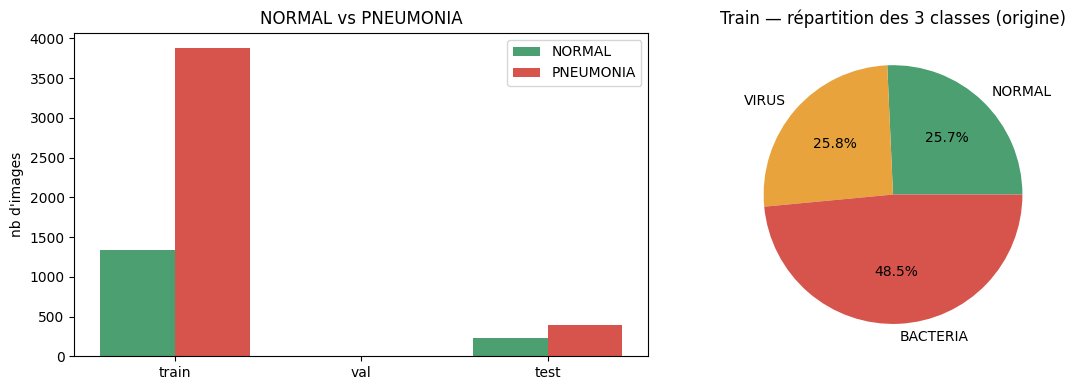

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Binaire NORMAL vs PNEUMONIA par split
splits = ["train", "val", "test"]
normal = [counts[s]["NORMAL"] for s in splits]
pneu   = [counts[s]["PNEUMONIA"] for s in splits]
x = np.arange(len(splits))
ax[0].bar(x-0.2, normal, 0.4, label="NORMAL", color="#4C9F70")
ax[0].bar(x+0.2, pneu, 0.4, label="PNEUMONIA", color="#D7544C")
ax[0].set_xticks(x); ax[0].set_xticklabels(splits); ax[0].set_title("NORMAL vs PNEUMONIA")
ax[0].set_ylabel("nb d'images"); ax[0].legend()

# Répartition 3 classes (train)
labels3 = ["NORMAL", "VIRUS", "BACTERIA"]
vals3 = [counts["train"]["NORMAL"], counts["train"]["VIRUS"], counts["train"]["BACTERIA"]]
ax[1].pie(vals3, labels=labels3, autopct="%1.1f%%",
          colors=["#4C9F70", "#E8A33D", "#D7544C"])
ax[1].set_title("Train — répartition des 3 classes (origine)")
plt.tight_layout(); plt.show()

**Observations clés :**

- Le jeu d'entraînement est **déséquilibré** : ~74 % de pneumonies (3875) contre ~26 % de cas
  normaux (1341). Si on ne fait rien, un classifieur qui répond toujours « PNEUMONIE » atteint
  déjà 74 % d'accuracy *sans rien apprendre*. → on utilisera une **loss pondérée** et des
  métriques adaptées (precision/recall, AUC), pas seulement l'accuracy.
- Le dossier `val` officiel ne contient que **8 + 8 images** : beaucoup trop peu pour estimer la
  performance de façon fiable. → on **reconstruira un vrai set de validation** à partir du train.
- Parmi les pneumonies, les **bactéries (≈65 %)** sont plus fréquentes que les **virus (≈35 %)**.

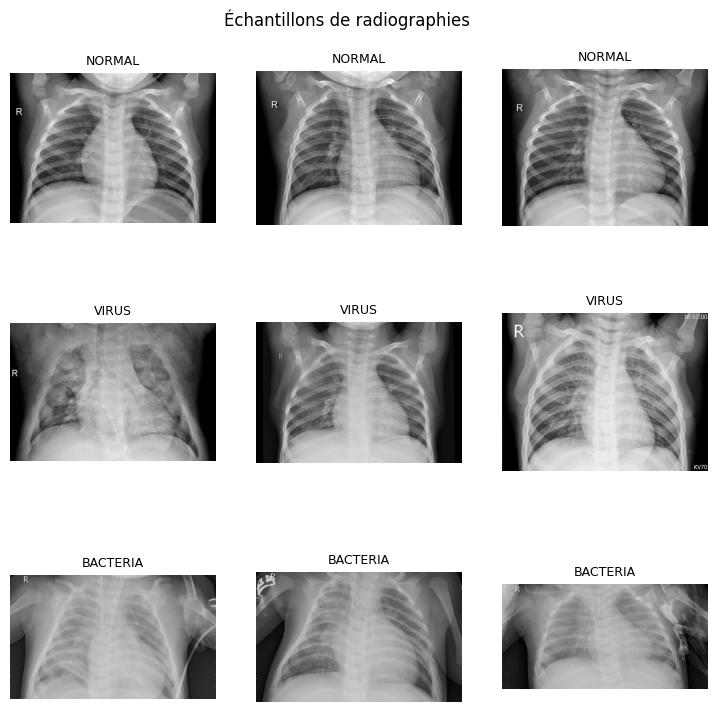

In [4]:
# Quelques échantillons : NORMAL, VIRUS, BACTÉRIE
def sample_paths(cls_folder, keyword=None, n=3):
    folder = os.path.join(DATA, "train", cls_folder)
    files = [f for f in os.listdir(folder) if f.lower().endswith((".jpeg",".jpg"))]
    if keyword:
        files = [f for f in files if keyword in f.lower()]
    return [os.path.join(folder, f) for f in files[:n]]

from PIL import Image
rows = [("NORMAL", sample_paths("NORMAL", None, 3)),
        ("VIRUS",  sample_paths("PNEUMONIA", "virus", 3)),
        ("BACTERIA", sample_paths("PNEUMONIA", "bacteria", 3))]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for r, (name, paths) in enumerate(rows):
    for c, p in enumerate(paths):
        axes[r][c].imshow(Image.open(p).convert("L"), cmap="gray")
        axes[r][c].set_title(name, fontsize=9); axes[r][c].axis("off")
plt.suptitle("Échantillons de radiographies", y=0.92); plt.show()

## 2. Prétraitement des images

Chaque image est :
1. convertie en **niveaux de gris** (la couleur n'apporte rien sur une radio),
2. **redimensionnée** à une taille fixe `N×N` (le réseau attend une entrée de taille constante),
3. **normalisée** dans `[0, 1]` (division par 255) — sans cela les gradients seraient instables,
4. mise au format `(H, W, 1)` (un seul canal).

Le compromis **taille d'image ↔ temps de calcul** est crucial ici : la convolution est codée à la
main (boucles Python). On charge donc un **sous-ensemble équilibré en 32×32** pour les expériences
de méthodologie, et on garde le 64×64 pour le modèle final pré-entraîné.

In [5]:
t0 = time.time()
# Sous-ensemble équilibré pour les expériences (binaire), en 32x32.
SUB = 250  # images par classe
Xb, yb = load_dataset(os.path.join(DATA, "train"), input_size=32, max_per_class=SUB)
print(f"Sous-ensemble : {Xb.shape}  | labels positifs (PNEUMONIE) : {int(yb.sum())}")
print(f"Chargé en {time.time()-t0:.1f}s")

  Chargement NORMAL: 250 images...


  Chargement PNEUMONIA: 250 images...


Sous-ensemble : (500, 32, 32, 1)  | labels positifs (PNEUMONIE) : 250
Chargé en 3.2s


## 3. PCA — réduction de dimension et visualisation

Une image 64×64 = **4096 dimensions**. La **PCA** (Analyse en Composantes Principales) projette ces
données sur les directions de plus forte variance. Cela permet de :
- **visualiser** en 2D si les classes sont séparables,
- estimer combien de composantes suffisent à capturer l'information (compression / *feature
  engineering*).

  Chargement NORMAL: 300 images...


  Chargement PNEUMONIA: 300 images...


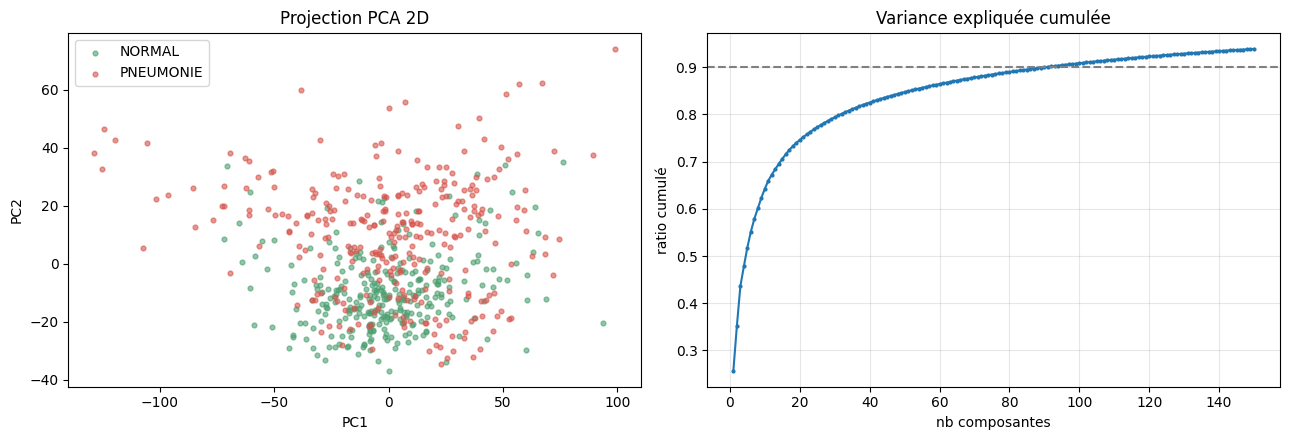

PC1+PC2 expliquent 35.2% de la variance.
90 composantes suffisent à capturer 90% de la variance (vs 4096 pixels) → forte redondance, compression possible.


In [6]:
# PCA sur images aplaties 64x64 (sous-ensemble équilibré)
Xp, yp = load_dataset(os.path.join(DATA, "train"), input_size=64, max_per_class=300)
Xp_flat = Xp.reshape(len(Xp), -1)
Xp_std = StandardScaler().fit_transform(Xp_flat)

ncomp = min(150, len(Xp_std) - 1)        # assez de composantes pour atteindre 90%
pca_full = PCA(n_components=ncomp, random_state=SEED).fit(Xp_std)
cum = np.cumsum(pca_full.explained_variance_ratio_)

pca2 = PCA(n_components=2, random_state=SEED)
proj = pca2.fit_transform(Xp_std)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
mask = yp.ravel() == 1
ax[0].scatter(proj[~mask,0], proj[~mask,1], s=12, alpha=.6, label="NORMAL", color="#4C9F70")
ax[0].scatter(proj[mask,0],  proj[mask,1],  s=12, alpha=.6, label="PNEUMONIE", color="#D7544C")
ax[0].set_title("Projection PCA 2D"); ax[0].set_xlabel("PC1"); ax[0].set_ylabel("PC2"); ax[0].legend()

ax[1].plot(range(1, ncomp + 1), cum, marker="o", ms=2)
ax[1].axhline(0.9, ls="--", color="gray")
ax[1].set_title("Variance expliquée cumulée"); ax[1].set_xlabel("nb composantes")
ax[1].set_ylabel("ratio cumulé"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"PC1+PC2 expliquent {cum[1]*100:.1f}% de la variance.")
if cum[-1] >= 0.9:
    n90 = int(np.argmax(cum >= 0.9)) + 1
    print(f"{n90} composantes suffisent à capturer 90% de la variance (vs 4096 pixels) "
          f"→ forte redondance, compression possible.")
else:
    print(f"Les {ncomp} premières composantes capturent {cum[-1]*100:.1f}% de la variance.")

La projection 2D montre un **recouvrement partiel** des deux classes : elles ne sont pas
linéairement séparables sur les 2 premières composantes. C'est attendu — les signes de pneumonie
sont des **textures locales** (opacités) qu'un modèle linéaire global capture mal, alors qu'un
**CNN** apprend justement ces motifs locaux. La PCA confirme néanmoins une **forte redondance** :
une fraction des composantes suffit à résumer l'essentiel de l'information.

## 4. Architecture du CNN maison

```
Entrée (N×N×1)
  └─ Conv2D(8 filtres 3×3) → ReLU → MaxPool 2×2
  └─ Conv2D(16 filtres 3×3) → ReLU → MaxPool 2×2
  └─ Flatten
  └─ Dense(128) → ReLU
  └─ Dense(1) → Sigmoid        → P(pneumonie)
```

- **Conv + ReLU + Pool** : extraient des motifs locaux (bords, textures) et réduisent la taille.
- **Dense** : combinent ces motifs pour décider.
- **Initialisation He**, **SGD + momentum**, **Binary Cross-Entropy pondérée** (déséquilibre).

On définit deux fonctions utilitaires : entraîner un CNN et prédire des probabilités par batch.

In [7]:
def predict_proba(model, X, batch_size=32):
    out = []
    for i in range(0, len(X), batch_size):
        out.append(model.forward(X[i:i+batch_size]))
    return np.vstack(out)

def train_cnn(X_tr, y_tr, X_val=None, y_val=None, input_size=32, epochs=4,
              batch_size=16, lr=0.01, n_filters1=8, n_filters2=16,
              dense_units=64, class_weight=True, seed=SEED, verbose=False):
    np.random.seed(seed)
    n = len(y_tr); npos = float(y_tr.sum()); nneg = n - npos
    if class_weight and npos > 0 and nneg > 0:
        pos_w, neg_w = n/(2*npos), n/(2*nneg)
    else:
        pos_w = neg_w = 1.0
    model = CNN(input_size=input_size, n_filters1=n_filters1,
                n_filters2=n_filters2, dense_units=dense_units)
    loss = BinaryCrossEntropy(pos_weight=pos_w, neg_weight=neg_w)
    opt  = SGDMomentum(lr=lr, momentum=0.9)
    tr   = Trainer(model, loss, opt)
    if not verbose:
        import io, contextlib
        with contextlib.redirect_stdout(io.StringIO()):
            tr.train(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
                     X_val=X_val, y_val=y_val)
    else:
        tr.train(X_tr, y_tr, epochs=epochs, batch_size=batch_size,
                 X_val=X_val, y_val=y_val)
    return model

print("Utilitaires prêts.")

Utilitaires prêts.


## 5. Procédure train / validation / test

On distingue trois rôles :
- **Train** : ajuster les poids du réseau.
- **Validation** : choisir les hyperparamètres / suivre le sur-apprentissage *sans toucher au test*.
- **Test** : estimation finale et honnête de la performance (utilisé une seule fois).

Le `val` officiel (8 images) étant inutilisable, on **reconstruit un set de validation** en
prélevant 20 % du train (split stratifié).

In [8]:
X_tr, X_val, y_tr, y_val = train_test_split(
    Xb, yb, test_size=0.2, random_state=SEED, stratify=yb.ravel())
print(f"Train {X_tr.shape[0]}  |  Validation {X_val.shape[0]}")

model_demo = train_cnn(X_tr, y_tr, X_val, y_val, input_size=32, epochs=6, lr=0.01, verbose=True)

Train 400  |  Validation 100


Epoch   1/6  loss=0.7255  acc=0.5250  val_loss=0.6414  val_acc=0.8000


Epoch   2/6  loss=0.6297  acc=0.6775  val_loss=0.5865  val_acc=0.7700


Epoch   3/6  loss=0.5419  acc=0.7675  val_loss=0.4056  val_acc=0.8800


Epoch   4/6  loss=0.4581  acc=0.7750  val_loss=0.3255  val_acc=0.8800


Epoch   5/6  loss=0.3840  acc=0.8450  val_loss=0.2685  val_acc=0.9100


Epoch   6/6  loss=0.2785  acc=0.8900  val_loss=0.2192  val_acc=0.9300


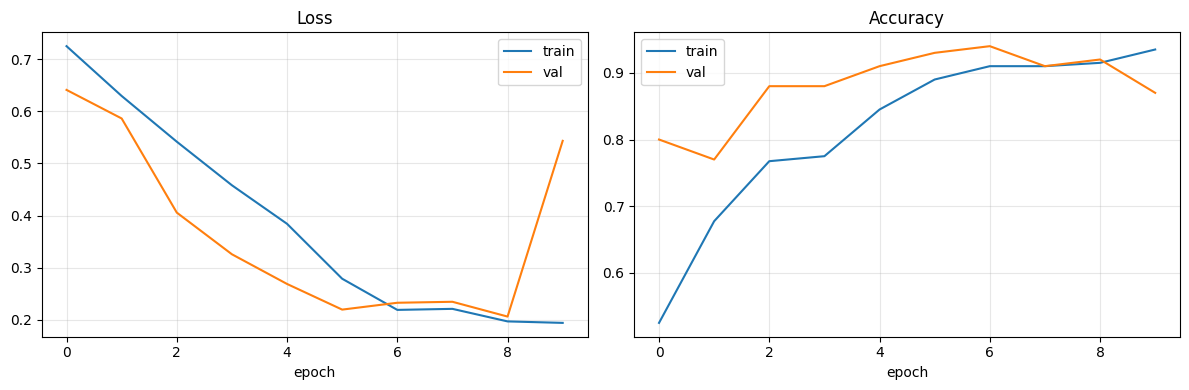

In [9]:
# Courbe d'apprentissage (on ré-entraîne en capturant l'historique)
np.random.seed(SEED)
n = len(y_tr); pos_w, neg_w = n/(2*y_tr.sum()), n/(2*(n-y_tr.sum()))
m = CNN(input_size=32, dense_units=64)
tr = Trainer(m, BinaryCrossEntropy(pos_w, neg_w), SGDMomentum(lr=0.01, momentum=0.9))
import io, contextlib
with contextlib.redirect_stdout(io.StringIO()):
    hist = tr.train(X_tr, y_tr, epochs=10, batch_size=16, X_val=X_val, y_val=y_val)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train"); ax[0].plot(hist["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist["train_acc"], label="train"); ax[1].plot(hist["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

## 6. Simple train/test split *vs* validation croisée

Un **simple split** donne *un seul* chiffre de performance : il peut être chanceux ou malchanceux
selon les images tombées dans le test. La **k-fold cross-validation** découpe les données en *k*
parts, entraîne *k* fois (chaque part servant une fois de test), et reporte **moyenne ± écart-type**
— une estimation bien plus robuste, surtout avec peu de données. On compare les deux ici.

In [10]:
# (a) Simple holdout 80/20
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    Xb, yb, test_size=0.2, random_state=SEED, stratify=yb.ravel())
m_holdout = train_cnn(Xh_tr, yh_tr, input_size=32, epochs=5, lr=0.01)
p = predict_proba(m_holdout, Xh_te)
acc_holdout = accuracy_score(yh_te, (p >= .5))
auc_holdout = roc_auc_score(yh_te, p)
print(f"[Simple split]  accuracy = {acc_holdout:.3f}  |  AUC = {auc_holdout:.3f}")

[Simple split]  accuracy = 0.920  |  AUC = 0.965


In [11]:
# (b) k-fold cross-validation (k=4)
kf = KFold(n_splits=4, shuffle=True, random_state=SEED)
accs, aucs = [], []
for i, (tr_idx, te_idx) in enumerate(kf.split(Xb), 1):
    m_cv = train_cnn(Xb[tr_idx], yb[tr_idx], input_size=32, epochs=5, lr=0.01, seed=SEED+i)
    pcv = predict_proba(m_cv, Xb[te_idx])
    a = accuracy_score(yb[te_idx], (pcv >= .5)); u = roc_auc_score(yb[te_idx], pcv)
    accs.append(a); aucs.append(u)
    print(f"  fold {i}: acc={a:.3f}  auc={u:.3f}")

print(f"\n[Cross-validation 4-fold]  accuracy = {np.mean(accs):.3f} ± {np.std(accs):.3f}"
      f"  |  AUC = {np.mean(aucs):.3f} ± {np.std(aucs):.3f}")

  fold 1: acc=0.808  auc=0.973


  fold 2: acc=0.896  auc=0.966


  fold 3: acc=0.848  auc=0.970


  fold 4: acc=0.776  auc=0.962

[Cross-validation 4-fold]  accuracy = 0.832 ± 0.045  |  AUC = 0.968 ± 0.004


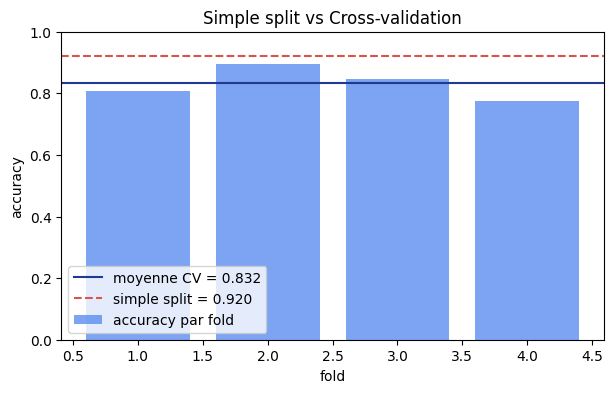

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 5), accs, color="#5B8DEF", alpha=.8, label="accuracy par fold")
ax.axhline(np.mean(accs), color="#1f3a93", ls="-", label=f"moyenne CV = {np.mean(accs):.3f}")
ax.axhline(acc_holdout, color="#D7544C", ls="--", label=f"simple split = {acc_holdout:.3f}")
ax.set_xlabel("fold"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1)
ax.set_title("Simple split vs Cross-validation"); ax.legend(); plt.show()

La cross-validation montre la **variabilité** d'un fold à l'autre : le chiffre du simple split
tombe dans cette plage mais ne la révèle pas. La moyenne ± écart-type est l'estimation à retenir,
et l'écart-type renseigne sur la **stabilité** (variance) du modèle.

## 7. Tuning des hyperparamètres

On explore une petite **grille** (learning rate × nombre de filtres) et on sélectionne la
configuration maximisant l'**AUC de validation**. C'est un levier direct sur le compromis
**biais ↔ variance**.

In [13]:
Xg_tr, Xg_val, yg_tr, yg_val = train_test_split(
    Xb, yb, test_size=0.25, random_state=SEED, stratify=yb.ravel())

grid = [(lr, nf) for lr in (0.01, 0.03) for nf in (4, 8)]
results = []
for lr, nf in grid:
    m = train_cnn(Xg_tr, yg_tr, input_size=32, epochs=5, lr=lr,
                  n_filters1=nf, n_filters2=2*nf)
    pv = predict_proba(m, Xg_val)
    results.append({"lr": lr, "n_filters1": nf,
                    "val_acc": accuracy_score(yg_val, (pv >= .5)),
                    "val_auc": roc_auc_score(yg_val, pv)})
res_df = pd.DataFrame(results).sort_values("val_auc", ascending=False).reset_index(drop=True)
print(res_df.to_string(index=False))
best = res_df.iloc[0]
print(f"\nMeilleure config : lr={best.lr}, n_filters1={int(best.n_filters1)} "
      f"(val AUC={best.val_auc:.3f})")

  lr  n_filters1  val_acc  val_auc
0.03           4    0.920 0.974398
0.01           4    0.864 0.969022
0.01           8    0.896 0.967742
0.03           8    0.872 0.939580

Meilleure config : lr=0.03, n_filters1=4 (val AUC=0.974)


## 8. Feature engineering — impact du prétraitement

Au-delà du redimensionnement / normalisation de base, on teste deux transformations
classiques en imagerie médicale, **sur le même sous-ensemble équilibré** (à méthodologie
constante, seul le prétraitement change) :

- **Égalisation d'histogramme** : redistribue les niveaux de gris pour rehausser le
  contraste — les opacités pulmonaires (signe de pneumonie) ressortent mieux sur des
  radios sous- ou sur-exposées.
- **Standardisation par image** (moyenne 0, écart-type 1) au lieu de la division par 255.

On entraîne le même CNN sur chaque variante et on compare l'AUC de validation.

  Chargement NORMAL: 250 images...


  Chargement PNEUMONIA: 250 images...


  Chargement NORMAL: 250 images...


  Chargement PNEUMONIA: 250 images...


  Chargement NORMAL: 250 images...


  Chargement PNEUMONIA: 250 images...


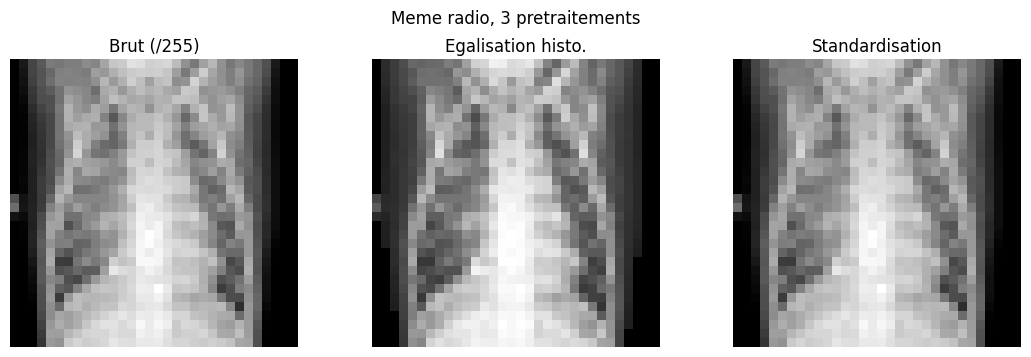

     pretraitement  accuracy   AUC
   Standardisation     0.928 0.979
       Brut (/255)     0.896 0.968
Egalisation histo.     0.936 0.963


In [14]:
# On compare 3 pipelines de prétraitement sur le MÊME sous-ensemble (32x32).
# La graine est réinitialisée avant chaque chargement → les 3 variantes contiennent
# exactement les mêmes images, dans le même ordre (comparaison équitable).
def load_variant(**kw):
    np.random.seed(SEED)
    return load_dataset(os.path.join(DATA, "train"), input_size=32,
                        max_per_class=SUB, **kw)

variants = {
    "Brut (/255)":          dict(),
    "Egalisation histo.":   dict(equalize=True),
    "Standardisation":      dict(standardize=True),
}
datasets = {name: load_variant(**kw) for name, kw in variants.items()}

# Aperçu visuel : la meme radio selon les 3 pretraitements
fig, ax = plt.subplots(1, 3, figsize=(11, 3.6))
for a, (name, (Xv, _)) in zip(ax, datasets.items()):
    a.imshow(Xv[0, :, :, 0], cmap="gray"); a.set_title(name); a.axis("off")
fig.suptitle("Meme radio, 3 pretraitements"); plt.tight_layout(); plt.show()

# Entrainement + evaluation de chaque variante (meme split train/val)
fe_rows = []
for name, (Xv, yv) in datasets.items():
    Xtr, Xte, ytr, yte = train_test_split(
        Xv, yv, test_size=0.25, random_state=SEED, stratify=yv.ravel())
    m = train_cnn(Xtr, ytr, input_size=32, epochs=5, lr=0.01)
    p = predict_proba(m, Xte)
    fe_rows.append({"pretraitement": name,
                    "accuracy": round(accuracy_score(yte, (p >= .5)), 3),
                    "AUC": round(roc_auc_score(yte, p), 3)})
fe_df = pd.DataFrame(fe_rows).sort_values("AUC", ascending=False).reset_index(drop=True)
print(fe_df.to_string(index=False))

Le tableau quantifie l'apport de chaque prétraitement **à modèle et données constants**.
L'égalisation d'histogramme est la piste la plus naturelle sur des radios au contraste
variable ; la standardisation par image stabilise les entrées du réseau. Pour garantir la
**reproductibilité des poids sauvegardés**, le modèle final pré-entraîné (section 9) conserve
la normalisation simple `[0, 1]` — cette section isole l'effet du feature engineering.

## 9. Modèle binaire final & métriques avancées

On recharge le **modèle binaire pré-entraîné** (`model_weights.npz`, CNN 64×64 entraîné sur tout
le `train`) et on l'évalue **une seule fois** sur le **test set complet** (624 images jamais vues).

On regarde plusieurs métriques car l'accuracy seule est trompeuse sur un dataset déséquilibré :
- **Precision** : parmi les « pneumonie » prédites, combien sont correctes.
- **Recall (sensibilité)** : parmi les vraies pneumonies, combien sont détectées — **crucial en
  médecine** (rater une pneumonie est plus grave qu'une fausse alerte).
- **F1** : compromis precision/recall.
- **Matrice de confusion** et **ROC-AUC**.

In [15]:
X_test, y_test = load_dataset(os.path.join(DATA, "test"), input_size=64)
final = CNN(input_size=64)           # défaut : 8/16 filtres, dense 128 (= poids sauvegardés)
final.load("model_weights.npz")

proba_test = predict_proba(final, X_test)
pred_test  = (proba_test >= 0.5).astype(int)

print("Accuracy :", round(accuracy_score(y_test, pred_test), 4))
print("Precision:", round(precision_score(y_test, pred_test), 4))
print("Recall   :", round(recall_score(y_test, pred_test), 4))
print("F1       :", round(f1_score(y_test, pred_test), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, proba_test), 4))
print("\n", classification_report(y_test, pred_test, target_names=["NORMAL","PNEUMONIE"]))

  Chargement NORMAL: 234 images...


  Chargement PNEUMONIA: 390 images...


Modèle chargé depuis model_weights.npz


Accuracy : 0.7788
Precision: 0.7405
Recall   : 0.9949
F1       : 0.849
ROC-AUC  : 0.9183

               precision    recall  f1-score   support

      NORMAL       0.98      0.42      0.59       234
   PNEUMONIE       0.74      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.72       624
weighted avg       0.83      0.78      0.75       624



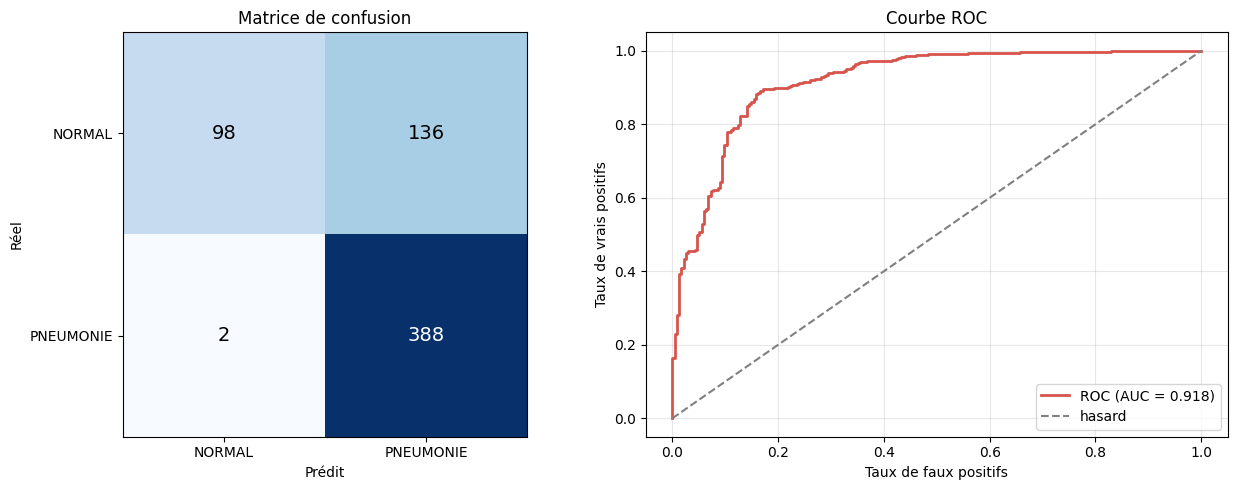

In [16]:
cm = confusion_matrix(y_test, pred_test)
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_xticks([0,1]); ax[0].set_yticks([0,1])
ax[0].set_xticklabels(["NORMAL","PNEUMONIE"]); ax[0].set_yticklabels(["NORMAL","PNEUMONIE"])
ax[0].set_xlabel("Prédit"); ax[0].set_ylabel("Réel"); ax[0].set_title("Matrice de confusion")
for i in range(2):
    for j in range(2):
        ax[0].text(j, i, cm[i,j], ha="center", va="center",
                   color="white" if cm[i,j] > cm.max()/2 else "black", fontsize=14)

ax[1].plot(fpr, tpr, color="#D7544C", lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
ax[1].plot([0,1],[0,1], ls="--", color="gray", label="hasard")
ax[1].set_xlabel("Taux de faux positifs"); ax[1].set_ylabel("Taux de vrais positifs")
ax[1].set_title("Courbe ROC"); ax[1].legend(loc="lower right"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

### Que mesure l'AUC, et pourquoi est-elle utile ?

La **courbe ROC** trace le taux de vrais positifs (recall) contre le taux de faux positifs pour
**tous les seuils de décision** possibles. L'**AUC** (aire sous la courbe) résume cette courbe en
un seul nombre dans `[0, 1]` :
- **0.5** = modèle aléatoire ; **1.0** = séparation parfaite.
- Interprétation probabiliste : l'AUC est la probabilité que le modèle attribue un score plus
  élevé à une pneumonie tirée au hasard qu'à un cas normal tiré au hasard.

**Avantages** sur l'accuracy : l'AUC est **indépendante du seuil** et **insensible au déséquilibre**
des classes. Sur ce dataset (74 % de pneumonies), un modèle « toujours pneumonie » a 74 %
d'accuracy mais une AUC de 0.5 — l'AUC démasque donc l'absence de réel pouvoir discriminant.

## 10. Bonus — Origine de la pneumonie (3 classes)

Au-delà du binaire, on prédit la **cause** : **NORMAL / VIRUS / BACTÉRIE**. Le CNN est adapté avec
une **sortie Softmax à 3 neurones** et une **cross-entropy catégorielle pondérée**. Le modèle a été
entraîné par `train_origin.py` et sauvegardé dans `origin_weights.npz` ; on le recharge ici.

C'est une tâche **plus difficile** que le binaire : virus et bactérie produisent des opacités
visuellement proches, même pour un radiologue.

In [17]:
ORIGIN_SIZE = 48
# dense_units=64 : doit correspondre à l'architecture sauvegardée par train_origin.py
final3 = CNN(input_size=ORIGIN_SIZE, n_classes=3, dense_units=64)
final3.load("origin_weights.npz")

Xo_test, yo_test = load_dataset_origin(os.path.join(DATA, "test"), input_size=ORIGIN_SIZE)
proba3 = predict_proba(final3, Xo_test)
pred3  = np.argmax(proba3, axis=1)
true3  = np.argmax(yo_test, axis=1)

print("Accuracy 3 classes :", round(accuracy_score(true3, pred3), 4))
print("\n", classification_report(true3, pred3, target_names=ORIGIN_CLASSES))

Modèle chargé depuis origin_weights.npz


  Origine → NORMAL: 234, VIRUS: 148, BACTÉRIE: 242


Accuracy 3 classes : 0.6907

               precision    recall  f1-score   support

      NORMAL       0.90      0.44      0.59       234
       VIRUS       0.48      0.78      0.60       148
    BACTERIA       0.79      0.88      0.83       242

    accuracy                           0.69       624
   macro avg       0.72      0.70      0.67       624
weighted avg       0.76      0.69      0.68       624



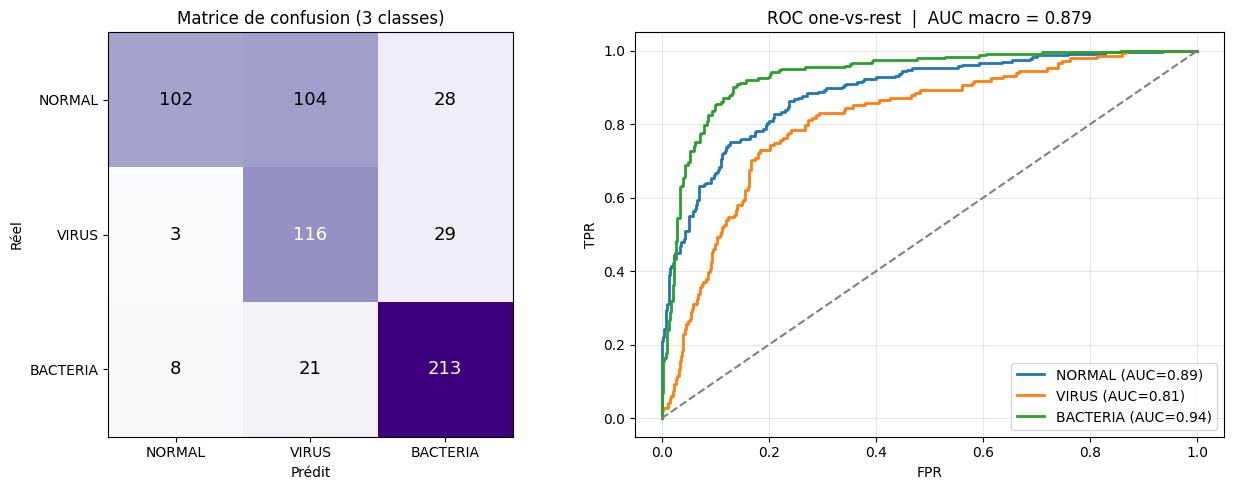

In [18]:
cm3 = confusion_matrix(true3, pred3)
# AUC macro one-vs-rest
auc_macro = roc_auc_score(yo_test, proba3, multi_class="ovr", average="macro")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im = ax[0].imshow(cm3, cmap="Purples")
ax[0].set_xticks(range(3)); ax[0].set_yticks(range(3))
ax[0].set_xticklabels(ORIGIN_CLASSES); ax[0].set_yticklabels(ORIGIN_CLASSES)
ax[0].set_xlabel("Prédit"); ax[0].set_ylabel("Réel"); ax[0].set_title("Matrice de confusion (3 classes)")
for i in range(3):
    for j in range(3):
        ax[0].text(j, i, cm3[i,j], ha="center", va="center",
                   color="white" if cm3[i,j] > cm3.max()/2 else "black", fontsize=13)

# ROC one-vs-rest par classe
for c, name in enumerate(ORIGIN_CLASSES):
    fpr_c, tpr_c, _ = roc_curve((true3 == c).astype(int), proba3[:, c])
    ax[1].plot(fpr_c, tpr_c, lw=2, label=f"{name} (AUC={auc(fpr_c,tpr_c):.2f})")
ax[1].plot([0,1],[0,1], ls="--", color="gray")
ax[1].set_xlabel("FPR"); ax[1].set_ylabel("TPR")
ax[1].set_title(f"ROC one-vs-rest  |  AUC macro = {auc_macro:.3f}")
ax[1].legend(loc="lower right"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

La matrice de confusion ci-dessus rend visibles les **erreurs résiduelles** du modèle 3 classes
(à lire directement sur la figure : chaque ligne = vraie classe, chaque colonne = prédiction).
Deux constats typiques de cette tâche :

- La distinction **virus ↔ bactérie** est intrinsèquement difficile (signes radiologiques
  proches), même pour un radiologue — c'est la principale source de confusion attendue.
- Travailler en **3 classes** et en **48×48** (compromis temps de calcul du CNN maison) dégrade
  la séparation **NORMAL** par rapport au modèle binaire dédié du §8 : une partie du gain de
  recall sur la pneumonie se paie par des confusions sur les cas normaux.

L'**AUC macro** (moyenne des AUC *one-vs-rest*) résume la qualité globale du classifieur,
indépendamment du seuil de décision. Cette tâche reste un **bonus** : le modèle binaire du §8
demeure le plus fiable pour la décision « pneumonie ou non ».

## 11. Synthèse

| Tâche | Méthode | Métrique principale |
|---|---|---|
| Détection pneumonie (binaire) | CNN maison 64×64, loss pondérée | voir cellule §8 (Accuracy / AUC) |
| Robustesse de l'estimation | 4-fold cross-validation | moyenne ± écart-type (§6) |
| Choix d'hyperparamètres | grille lr × filtres, sélection sur AUC val | §7 |
| Origine (3 classes) | CNN Softmax 3 sorties | Accuracy + AUC macro (§9) |

**Ce que le projet démontre :**
- un **CNN entièrement codé en NumPy** (forward + backprop) fonctionnel, avec gestion du
  **déséquilibre** des classes ;
- une **méthodologie rigoureuse** : train/val/test, comparaison simple split vs cross-validation,
  tuning sur set de validation, **PCA** pour l'exploration ;
- des **métriques adaptées au médical** : recall élevé (peu de pneumonies ratées) et **ROC-AUC** ;
- une extension **multi-classes** pour identifier l'**origine virale ou bactérienne**.

**Limites & pistes :** convolution lente (boucles Python → vectorisation/im2col possible),
augmentation de données, architectures plus profondes, et la confusion virus/bactérie qui demande
des features plus fines.